<a href="https://colab.research.google.com/github/AnushkaShrivastava28/Airbnd-Data-Analytics-Project/blob/main/1_Data_Analytics_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analytics Project** : **AirBnb Bookings Analysis**


# **Problem** **Statement**

Airbnb hosts face a lot of competition and need to understand what affects their bookings, prices, and customer satisfaction. It can be difficult for them to know which locations, room types, prices, and seasons attract more customers.

Without proper data analysis, hosts may miss opportunities to increase their revenue and improve their listings. Therefore, this project aims to analyze Airbnb data and find useful patterns that can help hosts make better decisions about pricing, location, room type, and customer reviews.

# 1.Analyzing my data

**Import Libraries**

In [174]:
# Import Libraries
import pandas as pd #Pandas – Used for loading, cleaning, manipulating, and analyzing structured data such as CSV and Excel files
import numpy as np #NumPy – Used for numerical calculations, arrays, and mathematical operations.
import matplotlib.pyplot as plt #Matplotlib – Used for creating graphs and visualizations such as bar charts, line charts, and histograms.
import seaborn as sns #Seaborn – Used for statistical data visualization and creating more informative charts.

**Dataset Loading**

In [175]:
from google.colab import files
import pandas as pd

data = pd.read_csv('Airbnb.csv')
print(data.head())

    id            name  host_id       host_name neighbourhood_group  \
0  362      Kavya Iyer    88018      Kavya Iyer              Jaipur   
1   74  Karan Malhotra    98647  Karan Malhotra     Central Kolkata   
2  375     Rohan Patel    78656     Rohan Patel              Jaipur   
3  156       Amit Jain    98150       Amit Jain             Udaipur   
4  105    Pooja Mishra    35430    Pooja Mishra              Bhopal   

  neighbourhood   latitude  longitude        room_type    price  \
0      C Scheme  26.879660  75.825309     Private room   2356.0   
1   Park Street  22.620204  88.292602  Entire home/apt   9209.0   
2    Mansarovar  26.881098  75.763871  Entire home/apt  10148.0   
3     Hathi Pol  24.592350  73.662297     Private room   1336.0   
4      MP Nagar  23.343002  77.448109  Entire home/apt  12236.0   

   minimum_nights  number_of_reviews last_review  reviews_per_month  \
0               4                 67  2023-06-24               2.34   
1               2           

**Dataset First View**

In [176]:
# Dataset First Look
data.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,362,Kavya Iyer,88018,Kavya Iyer,Jaipur,C Scheme,26.879660,75.825309,Private room,2356.0,4,67,2023-06-24,2.34,5,48
1,74,Karan Malhotra,98647,Karan Malhotra,Central Kolkata,Park Street,22.620204,88.292602,Entire home/apt,9209.0,2,0,NaN,NaN,4,115
2,375,Rohan Patel,78656,Rohan Patel,Jaipur,Mansarovar,26.881098,75.763871,Entire home/apt,10148.0,2,15,2025-12-08,1.66,1,361
3,156,Amit Jain,98150,Amit Jain,Udaipur,Hathi Pol,24.592350,73.662297,Private room,1336.0,30,59,2023-06-25,1.21,1,306
4,105,Pooja Mishra,35430,Pooja Mishra,Bhopal,MP Nagar,23.343002,77.448109,Entire home/apt,12236.0,1,57,2023-09-19,4.32,1,240


**Counting Rows and Cloumns of Dataset**

In [177]:
# Dataset Rows & Columns count: Use data.shape which returns number of(rows, columns)
data.shape
#You can seperately check
print("Number of Rows: ", data.shape[0])
print("Number of Columns: ", data.shape[1])

Number of Rows:  500
Number of Columns:  16


**Dataset Information**

In [178]:
#Dataset information
# It tells you:
# -Number of rows
# -Column names
# -Non-null values
# -Missing values indirectly
# -Data type of each variable
# -Memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              500 non-null    int64  
 1   name                            500 non-null    object 
 2   host_id                         500 non-null    int64  
 3   host_name                       491 non-null    object 
 4   neighbourhood_group             500 non-null    object 
 5   neighbourhood                   494 non-null    object 
 6   latitude                        500 non-null    float64
 7   longitude                       500 non-null    float64
 8   room_type                       500 non-null    object 
 9   price                           496 non-null    float64
 10  minimum_nights                  500 non-null    int64  
 11  number_of_reviews               500 non-null    int64  
 12  last_review                     402 

**Checking Duplicate Values**

In [179]:
# Dataset Duplicate Value Count
data.duplicated().sum()

np.int64(0)

**Missing Values/Null Values**

In [180]:
# Missing Values/Null Values Count
data.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,9
neighbourhood_group,0
neighbourhood,6
latitude,0
longitude,0
room_type,0
price,4


**Visualizing it as a heatmap**

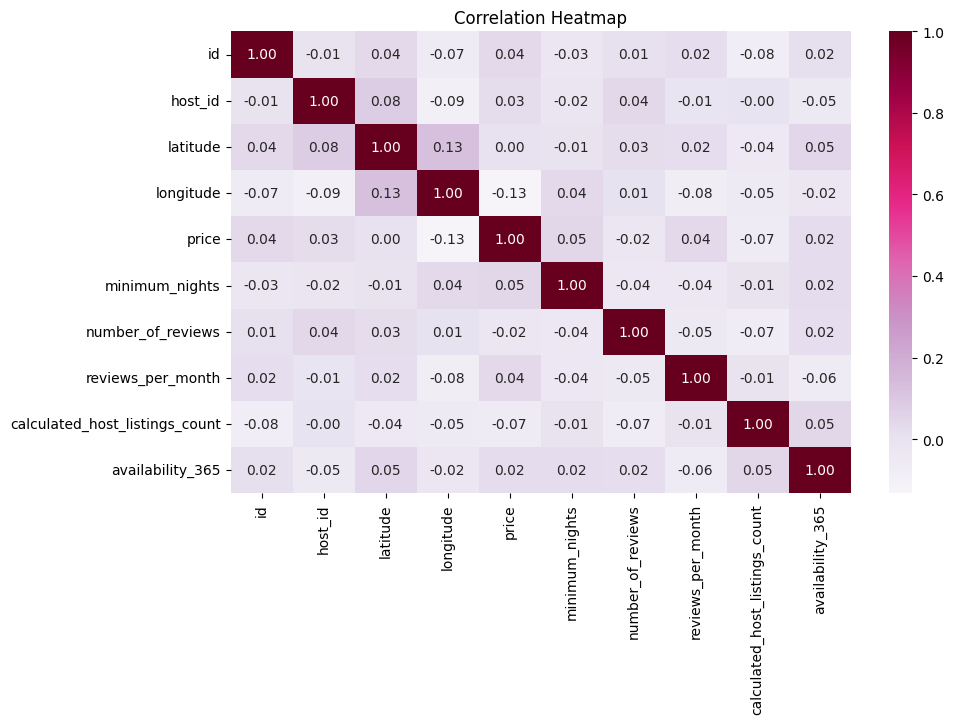

In [181]:
correlation = data.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="PuRd",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [182]:
#Checking the type of rooms
data.room_type.value_counts()

,count
room_type,
Entire home/apt,282
Private room,167
Hotel room,38
Shared room,13


In [183]:
#Checking all the neighborhood
data.neighbourhood_group.unique()

array(['Jaipur', 'Central Kolkata', 'Udaipur', 'Bhopal', 'Lucknow',
       'Central Chennai', 'Chandigarh', 'Noida', 'Central Pune',
       'West Hyderabad', 'Indore', 'Ahmedabad', 'South Delhi', 'Gurgaon',
       'Central Kerala', 'South Bengaluru', 'Western Suburbs',
       'North Goa'], dtype=object)

# 2.Understanding Variables

In [184]:
data.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

In [185]:
#Understanding Datatype of variable
# Common types:
# -int64 → whole numbers
# -float64 → decimal numbers
# -object → usually text/categories
# -bool → True/False
# -datetime64 → date/time
data.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


In [186]:
data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,500.000000,500.000000,500.000000,500.000000,496.000000,500.0000,500.000000,426.000000,500.000000,500.000000
mean,250.500000,54652.938000,22.379493,76.835444,6794.197581,3.1020,63.204000,1.980188,3.042000,177.680000
std,144.481833,25988.506711,5.989839,3.228957,4309.373230,4.1267,50.115482,1.472321,3.891339,107.614494
min,1.000000,10157.000000,9.885391,72.521060,587.000000,1.0000,0.000000,0.000000,1.000000,0.000000
25%,125.750000,31863.500000,18.506808,73.878370,3190.750000,1.0000,26.000000,0.810000,1.000000,79.000000
50%,250.500000,52616.500000,23.210265,76.796992,5590.500000,2.0000,56.500000,1.820000,2.000000,176.000000
75%,375.250000,78139.500000,26.962322,77.442381,10038.750000,3.0000,89.000000,2.957500,4.000000,275.000000
max,500.000000,99921.000000,30.785827,88.428532,18737.000000,30.0000,381.000000,7.230000,40.000000,363.000000


**Check Unique Values for each variable**

In [187]:
# Check Unique Values for each variable.
data.nunique()

,0
id,500
name,20
host_id,497
host_name,20
neighbourhood_group,18
neighbourhood,88
latitude,500
longitude,500
room_type,4
price,487


# 3.Data Wrangling

In [188]:
# testing >>Checking sum of null again we can delete it later
data.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,9
neighbourhood_group,0
neighbourhood,6
latitude,0
longitude,0
room_type,0
price,4


**Handling Missing Value**

In [189]:
# 1. Check missing values
data.isnull().sum()

# 2. Check percentage
(data.isnull().sum() / len(data)) * 100

# 3. Numerical columns
data['price'] = data['price'].fillna(data['price'].median())
data['reviews_per_month'] = data['reviews_per_month'].fillna(data['reviews_per_month'].median())

# 4. Categorical columns
data['host_name'] = data['host_name'].fillna(data['host_name'].mode()[0])
data['neighbourhood'] = data['neighbourhood'].fillna(data['neighbourhood'].mode()[0])

# 5. Verify
data.isnull().sum()

,0
id,0
name,0
host_id,0
host_name,0
neighbourhood_group,0
neighbourhood,0
latitude,0
longitude,0
room_type,0
price,0


# 4.Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

In [190]:
data.columns.tolist()

['id',
 'name',
 'host_id',
 'host_name',
 'neighbourhood_group',
 'neighbourhood',
 'latitude',
 'longitude',
 'room_type',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'last_review',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365']

**Analysis 1 >> Average Price by Neighbourhood Group**

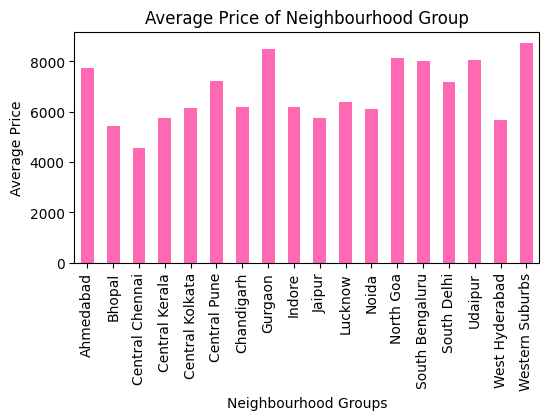

In [191]:
# Average Price by Neighbourhood Group

# Calculate average price by neighborhood group
avg_price_by_group = data.groupby('neighbourhood_group')['price'].mean()

# Plot the average price by neighborhood group
avg_price_by_group.plot(kind='bar', figsize=(6, 3),color='hotpink')
plt.title('Average Price of Neighbourhood Group')
plt.xlabel('Neighbourhood Groups')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.show()

**Analysis 2 >> Most Preferred Room Types**

In [192]:
room_type_counts = data['room_type'].value_counts()
room_type_counts

,count
room_type,
Entire home/apt,282
Private room,167
Hotel room,38
Shared room,13


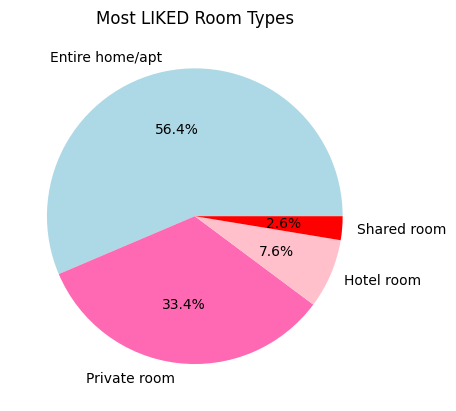

In [193]:
# Most Preferred Room Types

room_type_counts = data['room_type'].value_counts()

# Plot the pie chart
room_type_counts.plot(kind='pie', autopct='%1.1f%%', colors=['lightblue','hotpink','pink','red'])
plt.title('Most LIKED Room Types')
plt.ylabel('')
plt.show()


**Analysis - 3 >> Identify the most popular neighborhoods**

In [194]:
# Identify the most popular neighborhoods
#Since .value_counts() returns the neighborhoods sorted by frequency in descending order (from most to least frequent), .head(10)
top_neighborhoods = data['neighbourhood'].value_counts().head(10)
print("The most popular neighborhoods for Airbnb bookings in NYC are:")
print(top_neighborhoods)

The most popular neighborhoods for Airbnb bookings in NYC are:
neighbourhood
Saket               19
Mahanagar           12
Juhu                10
Rau                 10
Golf Course Road     9
Gomti Nagar          9
Jubilee Hills        9
Greater Kailash      9
TT Nagar             9
Andheri West         9
Name: count, dtype: int64


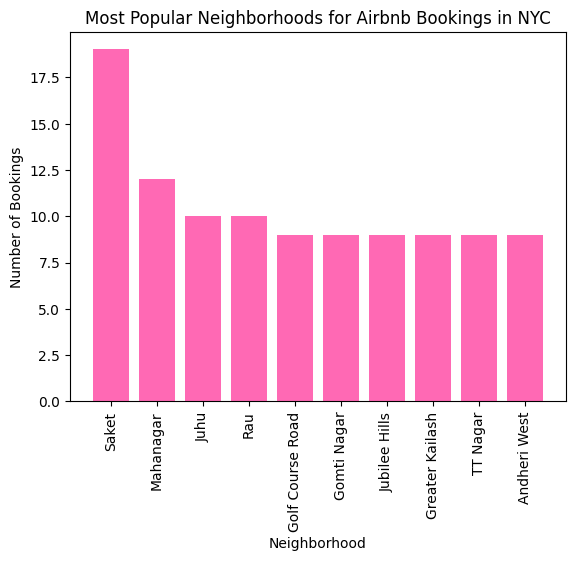

In [195]:
# Create a bar chart of the most popular neighborhoods
plt.bar(top_neighborhoods.index, top_neighborhoods.values , color = "hotpink")
plt.xticks(rotation=90)
plt.xlabel('Neighborhood')
plt.ylabel('Number of Bookings')
plt.title('Most Popular Neighborhoods for Airbnb Bookings in NYC')
plt.show()

**Analysis - 4 >> Trend of Average Listing Price Over month**

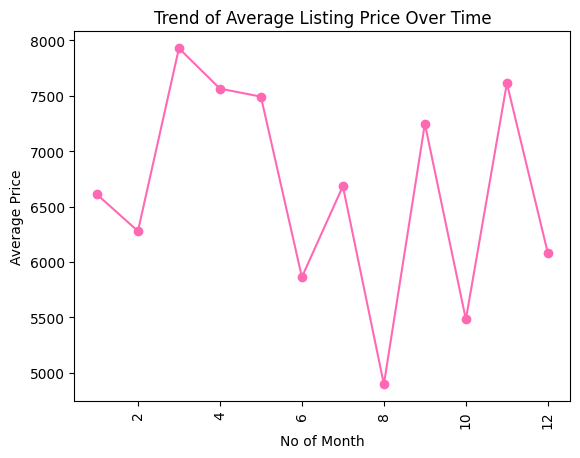

In [196]:
# Convert 'last_review' to datetime format
#errors='coerce', invalid or unparseable values are converted to NaT (Not a Time)
data['last_review'] = pd.to_datetime(data['last_review'], errors='coerce')

# Extract year and month from 'last_review'
data['month'] = data['last_review'].dt.month

# Calculate average price by year and month
avg_price_over_time = data.groupby('month')['price'].mean()

# Plot the trend of average price over time
avg_price_over_time.plot(kind='line', marker='o',color='hotpink')
plt.title('Trend of Average Listing Price Over Time')
plt.xlabel('No of Month')
plt.ylabel('Average Price')
plt.xticks(rotation=90)
plt.show()

**Analysis - 5 >> Price Variation by Neighborhood Group**

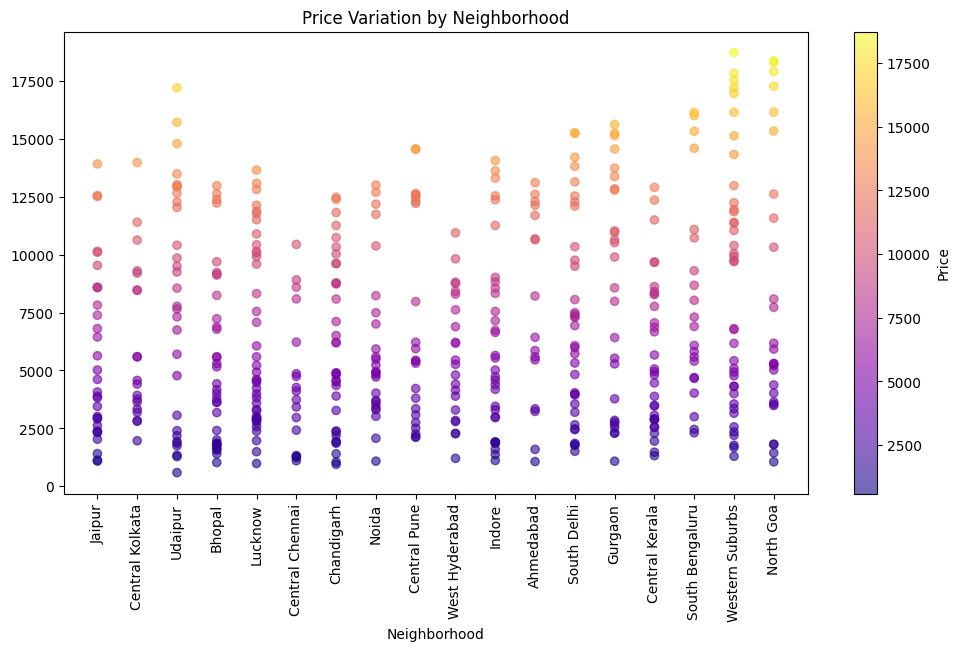

In [197]:
# Price Variation by Neighborhood Group

plt.figure(figsize=(12, 6))
scatter = plt.scatter(data['neighbourhood_group'],data['price'],alpha=0.6,c=data['price'],cmap='plasma')
plt.colorbar(scatter, label='Price')
plt.title('Price Variation by Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('')
plt.xticks(rotation=90)
plt.show()

**Analysis - 6 >> Visualizing Price vs number of reviews**

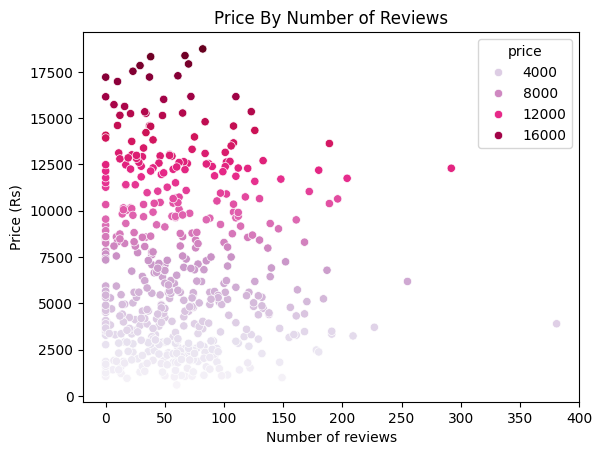

In [198]:
sns.scatterplot(data = data,x ='number_of_reviews',y ='price',hue='price' ,palette='PuRd' )
plt.title("Price By Number of Reviews")
plt.xlabel('Number of reviews')
plt.ylabel('Price (Rs)')
plt.show()

**Analysis - 7 >> Number of Hosts by Neighbourhood Group and Room Type**

# Number of Hosts by Neighbourhood Group and Room Type



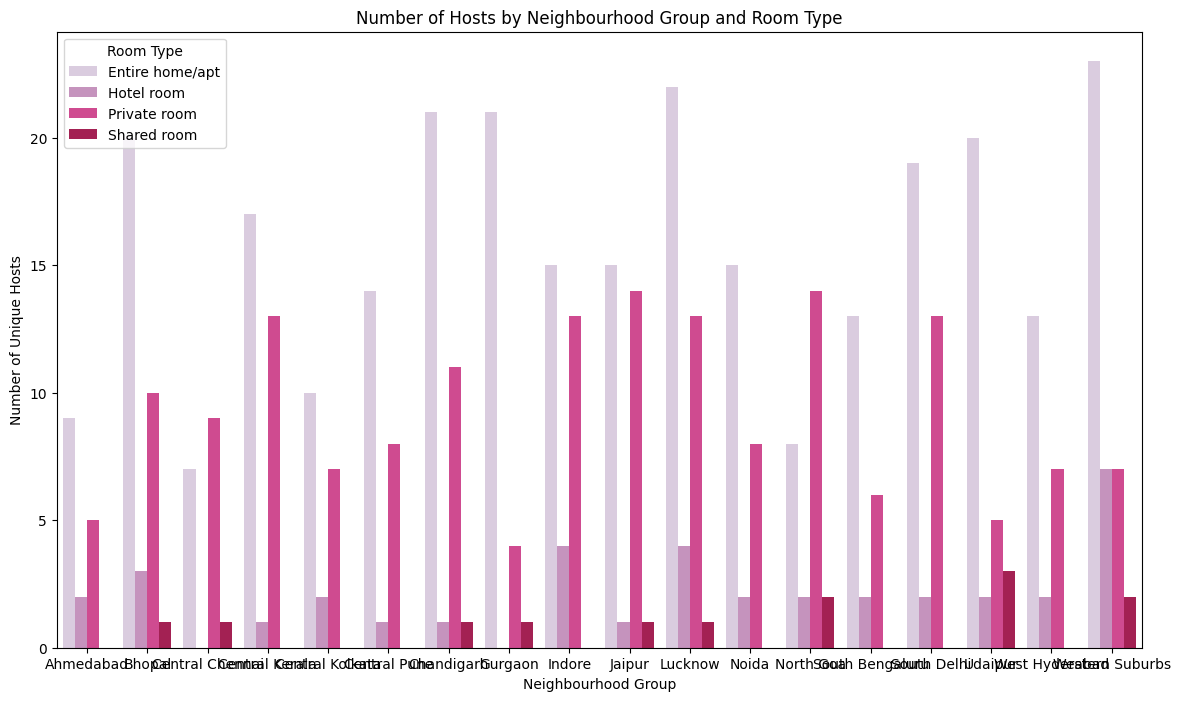

In [202]:

# Number of Hosts by Neighbourhood Group and Room Type

# Calculate the number of hosts for each combination of neighbourhood group and room type
host_counts = data.groupby(['neighbourhood_group', 'room_type'])['host_id'].nunique().reset_index()

# Create a bar plot to show the number of hosts
plt.figure(figsize=(14, 8))
sns.barplot(data=host_counts,x='neighbourhood_group', y='host_id', hue='room_type', palette='PuRd')
plt.title('Number of Hosts by Neighbourhood Group and Room Type')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Number of Unique Hosts')
plt.legend(title='Room Type')
plt.show()

**Chart Correlation Heatmap**

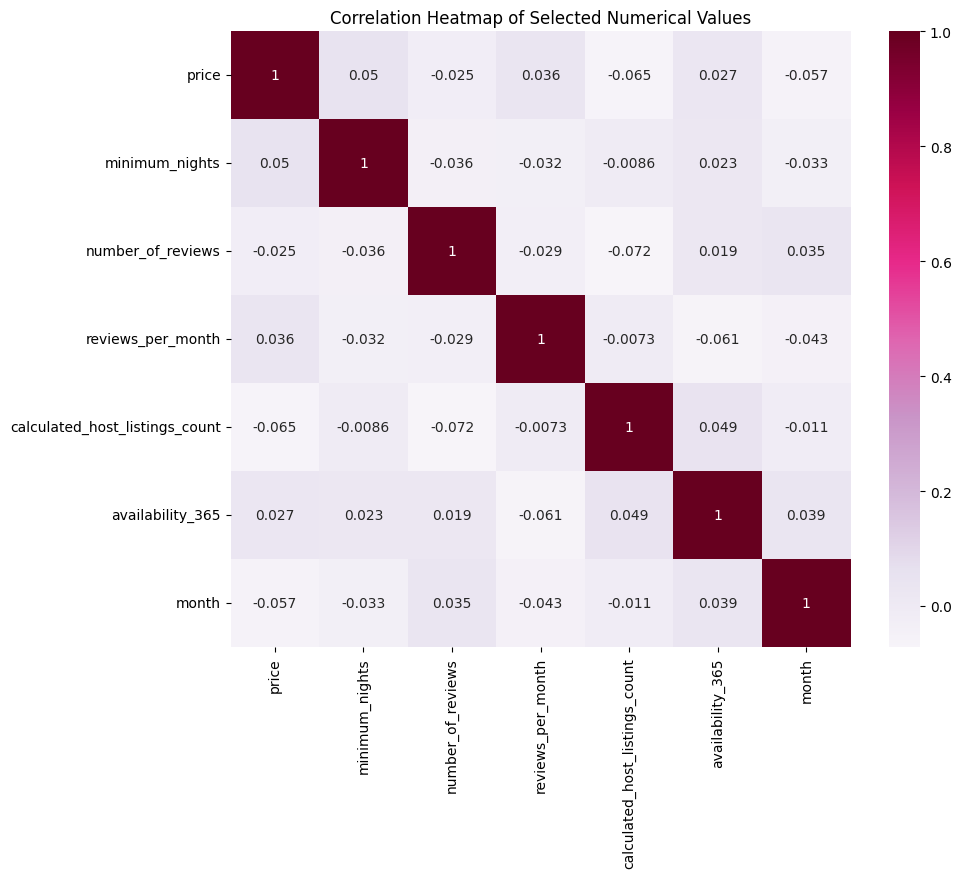

In [199]:
# Correlation Heatmap visualization code

# Drop the specified columns
df_numerical = data.drop(columns=['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type','last_review'])

# Compute the correlation matrix
corr_matrix = df_numerical.corr()

# Create a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='PuRd')
plt.title('Correlation Heatmap of Selected Numerical Values')
plt.show()

# Conclusion

This Airbnb analysis project helped us understand the main patterns in Airbnb listings, prices, locations, room types, and customer reviews.

1.Data Cleaning: Missing values were found in the dataset and handled properly to make the data ready for analysis.

2.Price: The price of a listing differs from one neighbourhood to another. This shows that location has a major effect on price.

3.Room Type: Entire home/apt was the most common room type, followed by Private room. Shared rooms and hotel rooms were less common.

4.Neighbourhood: Some areas had more Airbnb listings than others. Saket, Mahanagar, and Juhu were among the areas with higher listing activity in this dataset.

5.Reviews: Listings with more reviews generally also had higher reviews_per_month, showing a connection between overall reviews and recent review activity.

6.Price Relationship: Price did not have a strong relationship with most numerical variables. This means that Airbnb prices are affected by several factors together.

Overall Finding: The analysis shows that location, room type, price, and reviews are important factors when studying Airbnb listings.